In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import warnings; warnings.simplefilter('ignore')
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_visualize
import jsm_SHMR
import jsm_mcmc
import jsm_stats
import jsm_models
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg
import pygtc


In [4]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]
import pygtc

In [56]:
satgen = pd.read_csv("../../data/summary_tabs/SatGen_fid.csv")
bolshoi = pd.read_csv("../../data/summary_tabs/bolshoi.csv")
bolshoi.replace([np.inf, -np.inf], 0.0, inplace=True)
bolshoi = bolshoi[bolshoi["logc"] > np.log10(4)]

<Axes: xlabel='logc', ylabel='Density'>

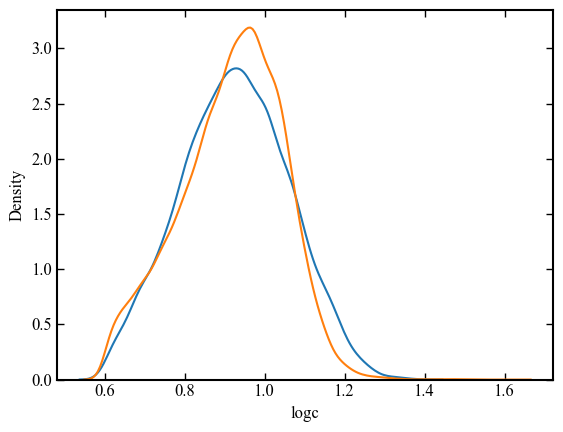

In [57]:

sns.kdeplot(satgen["logc"])
sns.kdeplot(bolshoi["logc"])


Mass bin 12.55-12.65: SatGen N=1000, Bolshoi N=3863
Mass bin 12.75-12.85: SatGen N=1000, Bolshoi N=2494
Mass bin 12.95-13.05: SatGen N=1000, Bolshoi N=1535
Mass bin 13.15-13.25: SatGen N=1000, Bolshoi N=1000
Mass bin 13.35-13.45: SatGen N=1000, Bolshoi N=626


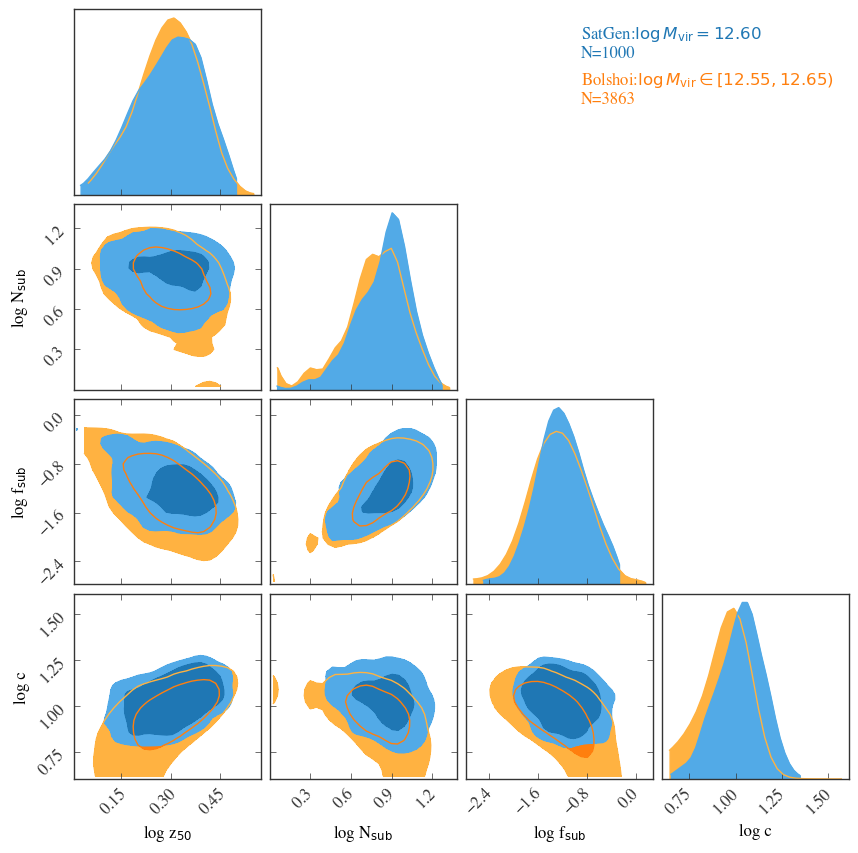

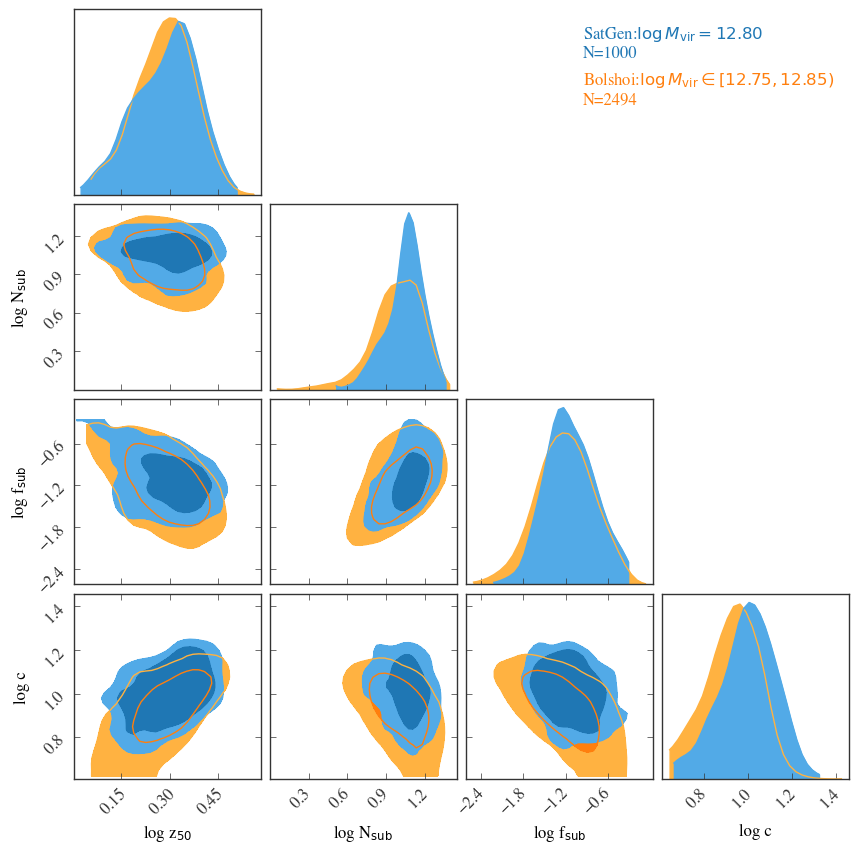

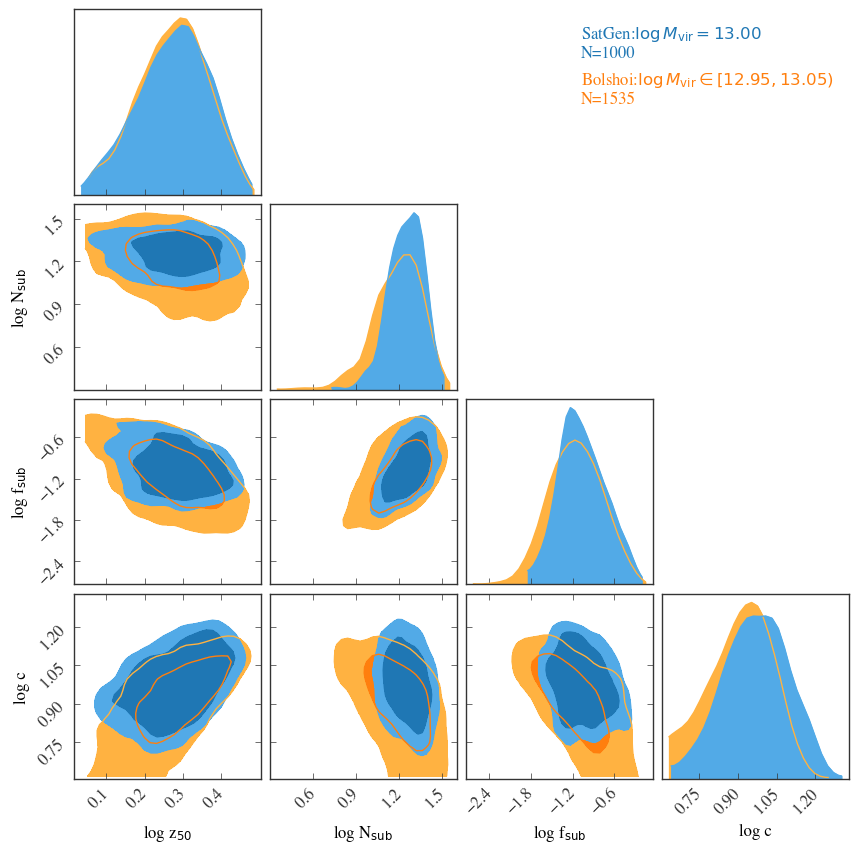

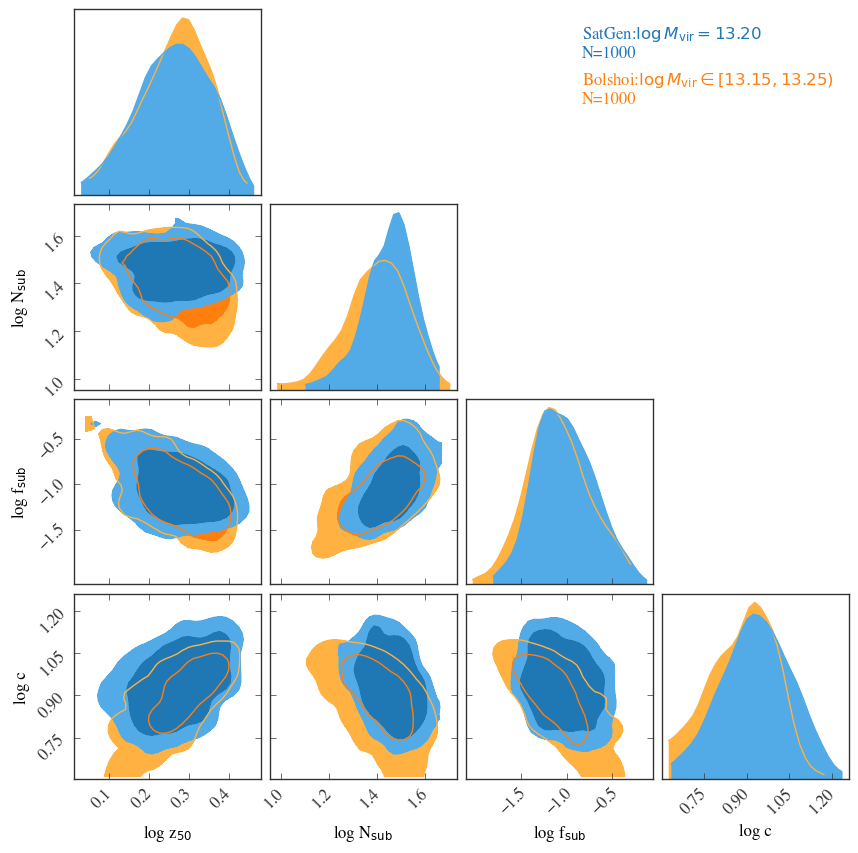

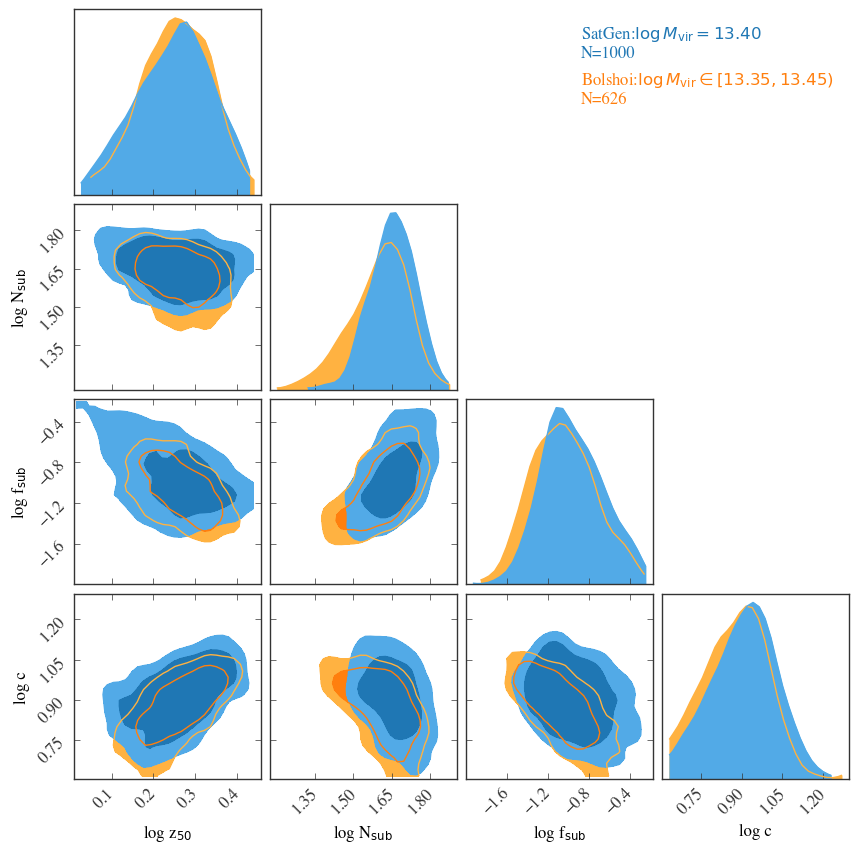

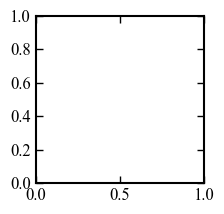

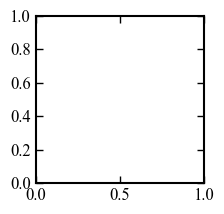

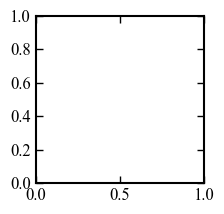

In [59]:
import pygtc

satgen_bins = [12.6, 12.8, 13.0, 13.2, 13.4, 13.6, 13.8, 14.0]
delta_bin = 0.1  # dex

names = [
    'log z$_{50}$',          # logz50
    'log N$_{\\rm sub}$',    # logNsub
    'log f$_{\\rm sub}$',    # logfsub
    'log c'                  # logc
]

for bin_center in satgen_bins:
    
    bin_min = bin_center - delta_bin/2
    bin_max = bin_center + delta_bin/2

    try:
        # select host bins
        satgen_subi = satgen[
            (satgen["logMvir"] >= bin_min) & (satgen["logMvir"] < bin_max)
        ][["logz50", "logNsub", "logfsub", "logc"]]

        bolshoi_subi = bolshoi[
            (bolshoi["logMvir"] >= bin_min) & (bolshoi["logMvir"] < bin_max)
        ][["logz50", "logNsub", "logfsub", "logc"]]

        # count number of hosts
        n_satgen = satgen_subi.shape[0]
        n_bolshoi = bolshoi_subi.shape[0]

        # include counts in the titles
        title_text_s = f"$\\log M_{{\\rm vir}} = {bin_center:.2f}$\nN={n_satgen}"
        title_text_b = f"$\\log M_{{\\rm vir}} \\in [{bin_min:.2f}, {bin_max:.2f})$\nN={n_bolshoi}"

        # corner plot
        corner_comp = pygtc.plotGTC(
            chains=[satgen_subi, bolshoi_subi],
            chainLabels=["SatGen:"+title_text_s, "Bolshoi:"+title_text_b],
            paramNames=names,   # <-- matched to dataframe column order
            smoothingKernel=1.4,
            figureSize=10,
            customTickFont={'family':'Times', 'size':12},
            customLegendFont={'family':'Times', 'size':12},
            customLabelFont={'family':'Times', 'size':12},
            mathTextFontSet=None,
            panelSpacing='loose',
            colorsOrder=["blues", "oranges"],
        )

        # print counts to console as well
        print(f"Mass bin {bin_min:.2f}-{bin_max:.2f}: SatGen N={n_satgen}, Bolshoi N={n_bolshoi}")

    except ValueError:
        pass